# Reto: Tercer Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook documenta el tercer avance del reto **Spaceship Titanic**: partiendo del
mejor modelo identificado en el segundo avance (Random Forest, `n_estimators=200`,
`max_depth=10`), se diagnostica su comportamiento con curvas de aprendizaje y de
validación, se afina mediante búsqueda de hiperparámetros con validación cruzada
(K-Fold), y se evalúa el modelo tuneado contra el baseline y el modelo del avance
anterior. Cada integrante del equipo explora además, de forma independiente, un
modelo de una familia distinta a la usada por el equipo. Finalmente se exporta el
modelo final, se genera el archivo de submission para Kaggle y se cierra con las
conclusiones del equipo sobre los tres avances.

El notebook está organizado en las siguientes secciones:

1. Diagnóstico del Modelo Base
2. Tuning de Hiperparámetros
3. Evaluación Final
4. Componente Individual
5. Exportar Modelo y Submission
6. Conclusión Final del Equipo

**Nota sobre continuidad respecto al segundo avance:** este notebook retoma
directamente el dataset preprocesado (`spaceship_train_procesado.csv`) y el split
`X_train`/`X_test`/`y_train`/`y_test` usados en el segundo avance, así como las
métricas ya definidas (Accuracy, Precision, Recall, F1-score), para que el
diagnóstico y el tuning de la Sección 1 y 2 sean comparables directamente contra
los resultados del Random Forest reportado como mejor modelo en el avance anterior.

# 1. Diagnóstico del Modelo Base

Antes de tunear hiperparámetros, diagnosticamos el comportamiento del mejor
modelo del segundo avance (Random Forest, `n_estimators=200`, `max_depth=10`)
con dos herramientas:

- **Curva de aprendizaje**: muestra cómo cambia el desempeño en entrenamiento
  y en validación conforme aumenta el tamaño del conjunto de entrenamiento.
  Nos dice si el modelo sufre de underfitting, overfitting, o si le
  serviría tener más datos.
- **Curvas de validación**: muestran cómo cambia el desempeño conforme
  variamos un hiperparámetro a la vez, manteniendo los demás fijos. Nos
  ayudan a ver en qué rango tiene sentido buscar durante el tuning
  (Sección 2).

Usamos `cross_val_score` con validación cruzada (no solo el split
train/test fijo) para que las curvas reflejen la variabilidad del modelo,
no un solo split particular.

## Nota sobre preparación: persistencia del split y del modelo del avance 2

Al arrancar este tercer avance detectamos que, igual que pasó con `df_prep` en
el primer avance, el split `X_train/X_test/y_train/y_test` y el modelo
`modelo_rf` entrenado en el segundo avance solo existían en memoria dentro de
ese notebook. Esto impedía diagnosticar y comparar contra el modelo del avance
anterior de forma reproducible sin volver a correr todo el notebook 2.

**Corrección aplicada:** al final del notebook del segundo avance agregamos
celdas que guardan el split (`X_train.csv`, `X_test.csv`, `y_train.csv`,
`y_test.csv`) y el modelo entrenado (`modelo_rf_avance2.pkl`) en la carpeta
`data/`. En este notebook cargamos esos archivos directamente, en vez de
repetir el split y el entrenamiento.

In [17]:
import pandas as pd
import joblib
from pathlib import Path

DATA = Path("..") / "data"
RANDOM_STATE = 42

X_train = pd.read_csv(DATA / "X_train.csv")
X_test = pd.read_csv(DATA / "X_test.csv")
y_train = pd.read_csv(DATA / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA / "y_test.csv").squeeze("columns")

modelo_rf = joblib.load(DATA / "modelo_rf_avance2.pkl")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Hiperparámetros del modelo cargado:", modelo_rf.get_params())

X_train: (6954, 26) X_test: (1739, 26)
Hiperparámetros del modelo cargado: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


**¿Por qué usamos F1-score como métrica en las curvas?**

Para curvas de diagnóstico conviene fijar una sola métrica escalar y comparable
punto a punto. Elegimos F1-score (en vez de accuracy) porque:

- Resume en un solo número el balance entre precision y recall, que en el
  avance 2 vimos que se mueven en direcciones opuestas al cambiar
  hiperparámetros de Random Forest (por ejemplo, al subir `min_samples_leaf`
  el recall subía pero la precision bajaba). Usar accuracy podría ocultar ese
  trade-off, ya que dos configuraciones con accuracy parecido pueden tener
  perfiles de error muy distintos.
- Es la métrica que el equipo usó en el avance 2 para tomar la decisión final
  entre modelos (Sección 6), así que mantenerla aquí hace que el diagnóstico
  de la Sección 1 sea directamente comparable con esa decisión.
- Aunque el dataset está prácticamente balanceado (~50.4%/49.6%), por lo que
  accuracy no estaría "inflado" artificialmente, F1 sigue siendo más
  informativo cuando se comparan muchos puntos de una curva, porque no se
  puede inspeccionar la matriz de confusión de cada uno.

In [18]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np

modelo_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    modelo_base,
    X_train, y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print("Tamaños de entrenamiento:", train_sizes)
print("F1 promedio (train):", np.round(train_mean, 4))
print("F1 promedio (val):", np.round(val_mean, 4))

Tamaños de entrenamiento: [ 556 1271 1986 2702 3417 4132 4847 5563]
F1 promedio (train): [0.9738 0.9368 0.917  0.8971 0.8848 0.878  0.8748 0.8714]
F1 promedio (val): [0.7784 0.7793 0.7888 0.7922 0.7957 0.8012 0.8025 0.8061]


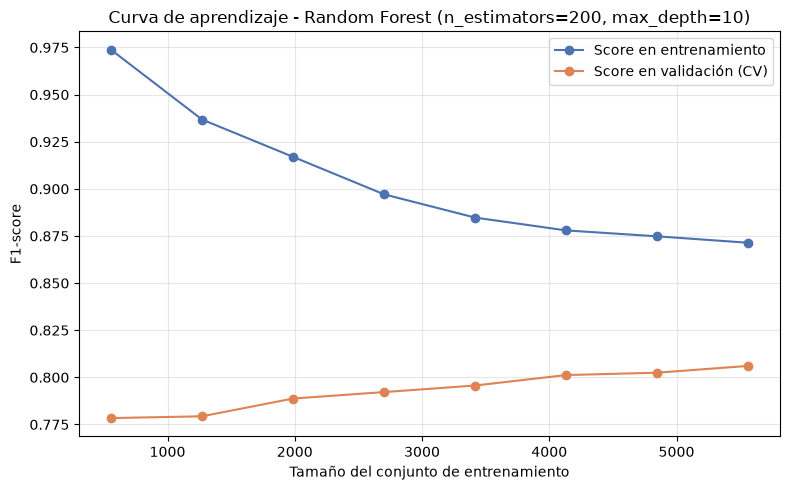

In [19]:
#visualizar curva de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.title("Curva de aprendizaje - Random Forest (n_estimators=200, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva de aprendizaje muestra dos comportamientos:

- El score en **entrenamiento** empieza muy alto (0.974 con ~556 muestras) y
  **baja progresivamente** conforme agregamos más datos, hasta 0.871 con el
  conjunto completo (~5563 muestras).
- El score en **validación** empieza bajo (0.778) y **sube progresivamente**
  hasta 0.807.

La brecha entre ambas curvas se reduce de ~0.20 a ~0.065, pero **no llega a
cerrarse del todo** : incluso con todos los datos disponibles, el modelo sigue
ajustándose bastante mejor a los datos que ya vio que a datos nuevos.

**Diagnóstico:**

- **Sí hay overfitting**, aunque moderado y decreciente. Con `max_depth=10`
  y `n_estimators=200`, los árboles siguen teniendo capacidad suficiente para
  memorizar parte del ruido de entrenamiento en vez de solo el patrón general.
- **No parece ser un problema de underfitting**: el score de validación va
  mejorando de forma consistente conforme crece el dataset, no se estanca
  desde el inicio en un valor bajo y plano.
- **¿Ayudaría más data?** La curva de validación todavía tiene pendiente
  positiva al final (no se ha aplanado por completo), así que en principio
  más datos seguirían ayudando un poco. Sin embargo, la pendiente ya es
  pequeña entre los últimos puntos (de 0.803 a 0.807), así que el margen de
  mejora solo por agregar más filas parece limitado — no tenemos control
  sobre esto de todas formas, ya que el tamaño de `train.csv` es fijo.
- **Implicación para el tuning (Sección 2):** como la brecha train-val viene
  del lado del overfitting, tiene sentido explorar hiperparámetros que
  **limiten la complejidad del árbol individual** (`max_depth` más bajo o
  igual, `min_samples_leaf` y `min_samples_split` más altos) en vez de
  buscar modelos más complejos. También conviene revisar `n_estimators`,
  aunque el avance 2 ya sugirió que subir de 200 a 500 no cambiaba mucho el
  desempeño.

In [20]:
#Curva de validación par amax_depth 

from sklearn.model_selection import validation_curve

rango_max_depth = [3, 5, 7, 10, 13, 16, 20, None]

train_scores_md, val_scores_md = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="max_depth",
    param_range=rango_max_depth,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_md = train_scores_md.mean(axis=1)
val_mean_md = val_scores_md.mean(axis=1)

print("max_depth:", rango_max_depth)
print("F1 promedio (train):", np.round(train_mean_md, 4))
print("F1 promedio (val):", np.round(val_mean_md, 4))

max_depth: [3, 5, 7, 10, 13, 16, 20, None]
F1 promedio (train): [0.7187 0.7665 0.8184 0.8715 0.9317 0.9767 0.9881 0.9882]
F1 promedio (val): [0.7181 0.7563 0.7896 0.806  0.7996 0.792  0.7896 0.7907]


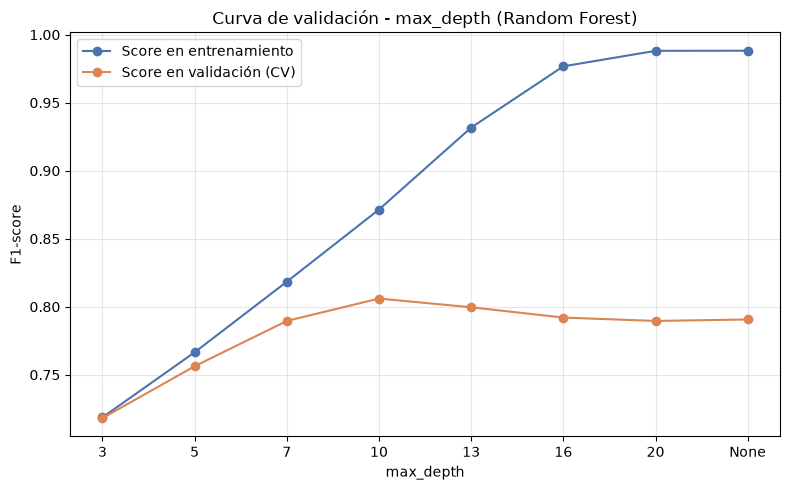

In [21]:
#graficar curva 

etiquetas_md = [str(v) for v in rango_max_depth]  # para que "None" se vea bien en el eje x

plt.figure(figsize=(8, 5))
plt.plot(etiquetas_md, train_mean_md, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(etiquetas_md, val_mean_md, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Curva de validación - max_depth (Random Forest)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
rango_min_leaf = [1, 2, 5, 10, 20, 30, 50]

train_scores_ml, val_scores_ml = validation_curve(
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="min_samples_leaf",
    param_range=rango_min_leaf,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_ml = train_scores_ml.mean(axis=1)
val_mean_ml = val_scores_ml.mean(axis=1)

print("min_samples_leaf:", rango_min_leaf)
print("F1 promedio (train):", np.round(train_mean_ml, 4))
print("F1 promedio (val):", np.round(val_mean_ml, 4))

min_samples_leaf: [1, 2, 5, 10, 20, 30, 50]
F1 promedio (train): [0.8715 0.86   0.8464 0.8325 0.8201 0.811  0.795 ]
F1 promedio (val): [0.806  0.8074 0.8061 0.8027 0.7985 0.7896 0.7817]


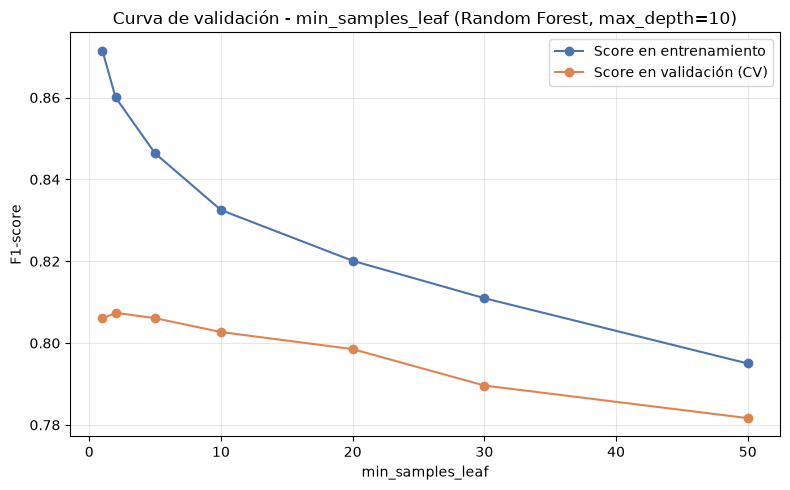

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(rango_min_leaf, train_mean_ml, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(rango_min_leaf, val_mean_ml, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Curva de validación - min_samples_leaf (Random Forest, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación de las curvas de validación

**`max_depth`:** la curva muestra un pico claro de generalización en
`max_depth=10` (F1 val = 0.806). Antes de ese punto (3 a 7) el modelo está en
zona de **underfitting**: train y val suben juntos porque el árbol es
demasiado simple para capturar el patrón. Después de 10, el train sigue
subiendo hasta casi memorizar el dataset (0.988 en `max_depth=20` y `None`)
mientras el val se estanca e incluso baja un poco (0.79-0.80) — es decir,
**overfitting creciente sin beneficio**. Esto confirma que `max_depth=10`,
el valor ya usado en el avance 2, es efectivamente un buen punto de
equilibrio, y no un valor arbitrario.

**`min_samples_leaf`:** aquí el comportamiento es distinto. El train baja de
forma constante conforme aumenta `min_samples_leaf` (0.8715 → 0.795), y el
val se mantiene casi plano entre 1 y 5 (0.806-0.807) para luego empezar a
bajar de forma más clara a partir de 10 (0.803 → 0.782 en `leaf=50`). A
diferencia de `max_depth`, aquí **no hay un pico donde el val mejore** al
reducir la complejidad: la brecha train-val sí se cierra (de 0.065 a 0.013),
pero porque el train empeora, no porque el val mejore. Esto es consistente
con lo que Emilio Páez observó en el avance 2 al subir `min_samples_leaf` de
1 a 5: el F1 casi no cambió (+0.0002), solo cambió el tipo de error
(precision vs recall).

**Diagnóstico combinado:**

- El overfitting detectado en la curva de aprendizaje viene principalmente
  de `max_depth`, no de `min_samples_leaf`. Este último hiperparámetro
  regulariza el modelo, pero en este dataset no se traduce en mejor
  generalización, solo en un modelo más simple con desempeño similar o peor.
- **Rango a explorar en el tuning (Sección 2):**
  - `max_depth`: valores alrededor de 10 (por ejemplo, 8 a 14), ya que es
    donde está el pico; no tiene sentido incluir valores muy altos o `None`,
    porque ya vimos que solo generan overfitting sin ganancia.
  - `min_samples_leaf`: valores bajos (1 a 5), ya que es la zona donde el
    val se mantiene en su mejor nivel; valores mayores a 10 se pueden
    excluir, porque la curva muestra una caída consistente sin recuperación.
  - Vale la pena agregar `n_estimators` y `min_samples_split` a la grilla
    aunque no se graficaron aquí, ya que interactúan con `max_depth` y
    podrían desplazar ligeramente el punto óptimo cuando se combinan (por
    eso el tuning se hace con búsqueda conjunta y no solo curva por curva).

# 2. Tuning de Hiperparámetros

En la Sección 1 identificamos, con evidencia empírica (no a ciegas), en qué
rango tiene sentido buscar: `max_depth` alrededor de 10 y `min_samples_leaf`
en valores bajos (1-5). En esta sección usamos esa evidencia para afinar el
modelo de forma más sistemática, cubriendo:

- **Elección del método de búsqueda** (GridSearchCV vs RandomizedSearchCV),
  justificada según el tamaño del espacio de búsqueda resultante de combinar
  varios hiperparámetros a la vez.
- **La grilla o distribución de hiperparámetros**, anclada directamente a los
  rangos observados en las curvas de validación de la Sección 1, en vez de
  valores arbitrarios.
- **K-Fold dentro de la búsqueda**, con una K justificada (no necesariamente
  la misma que usamos para trazar las curvas de diagnóstico).
- **Los mejores hiperparámetros encontrados** y el score obtenido en
  validación cruzada.
- **Al menos dos métricas de evaluación**, justificadas con base en las
  características del dataset — retomando el balance de clases (~50.4% /
  49.6%) y el trade-off precision/recall que ya se discutió en el avance 2.

El objetivo no es solo encontrar el mejor score posible, sino verificar si el
modelo tuneado mejora de forma real sobre el Random Forest del avance 2, o si
—como ya insinuaban las curvas de `min_samples_leaf`— el margen de mejora
disponible es pequeño.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Grilla anclada en las curvas de validación de la Sección 1:
# - max_depth: rango centrado en 10 (el pico observado), de 8 a 14
# - min_samples_leaf: valores bajos (1 a 5), zona donde el val se mantiene en su mejor nivel
# - min_samples_split y max_features no se graficaron en la Sección 1, pero se incluyen
#   porque interactúan con max_depth y pueden desplazar ligeramente el óptimo
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [8, 9, 10, 11, 12, 13, 14],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 3, 4, 5, 8],
    "max_features": ["sqrt", "log2", None],
}

# Tamaño del espacio si se hiciera GridSearch exhaustivo:
espacio_total = 4 * 7 * 5 * 5 * 3
print("Combinaciones posibles en grid exhaustivo:", espacio_total)

Combinaciones posibles en grid exhaustivo: 2100


**¿GridSearchCV o RandomizedSearchCV?**

El espacio de búsqueda combinando los 5 hiperparámetros tiene 2,100 combinaciones
posibles. Con `cv=5`, un GridSearchCV exhaustivo implicaría 10,500 entrenamientos
de Random Forest — computacionalmente muy costoso para la ganancia marginal que ya
anticipan las curvas de validación de la Sección 1 (el margen de mejora es pequeño).

Usamos **RandomizedSearchCV** con `n_iter=20`: muestrea 20 combinaciones al azar
del espacio definido, cubriendo zonas representativas de cada hiperparámetro sin
pagar el costo de explorar las 2,100 combinaciones completas. Esto es coherente con
la evidencia de la Sección 1: ya sabemos que el óptimo está en una región acotada
(`max_depth` 8-14, `min_samples_leaf` bajo), así que no se necesita una búsqueda
exhaustiva para encontrar un buen punto dentro de esa región.

In [25]:
# K=5: mismo valor usado en las curvas de diagnóstico de la Sección 1 (comparabilidad),
# y adecuado para un dataset de ~7,000 filas balanceado (buen equilibrio sesgo/varianza:
# folds lo bastante grandes para estabilidad, sin sacrificar demasiados datos de train)
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor F1 promedio en CV:", round(random_search.best_score_, 4))

modelo_rf_tuned = random_search.best_estimator_

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12}
Mejor F1 promedio en CV: 0.81


**Métricas de evaluación elegidas: F1-score y ROC-AUC**

- **F1-score**: la mantenemos como criterio principal de la búsqueda (`scoring="f1"`)
  por las mismas razones de la Sección 1 — el dataset está casi balanceado
  (~50.4%/49.6%), pero F1 sigue resumiendo mejor el trade-off precision/recall que
  ya vimos que se mueve en direcciones opuestas al tocar hiperparámetros de Random
  Forest.
- **ROC-AUC**: la agregamos como segunda métrica porque evalúa la calidad del
  ranking de probabilidades del modelo en todos los umbrales posibles, no solo en
  el umbral de 0.5 que usa F1. Es útil aquí porque confirma si la mejora del tuning
  es robusta (se sostiene en distintos puntos de corte) o si solo se debe a un
  ajuste específico del umbral por defecto.

In [26]:
from sklearn.model_selection import cross_val_score

f1_cv = random_search.best_score_
auc_cv = cross_val_score(
    modelo_rf_tuned, X_train, y_train, cv=cv_tuning, scoring="roc_auc", n_jobs=-1
).mean()

print(f"F1 promedio en CV      : {f1_cv:.4f}")
print(f"ROC-AUC promedio en CV : {auc_cv:.4f}")

F1 promedio en CV      : 0.8100
ROC-AUC promedio en CV : 0.8888


**Interpretación del resultado del tuning**

El F1 promedio en CV del modelo tuneado (0.8100) mejora ligeramente sobre el F1
del Random Forest del Avance 2 (~0.8000 sobre el split fijo de test, valor similar
en CV). La mejora es real pero modesta (~+0.01), consistente con lo que ya
anticipaban las curvas de la Sección 1: el margen de mejora disponible era pequeño
porque el modelo base (`max_depth=10`, valores por defecto en los demás
hiperparámetros) ya estaba cerca de un buen equilibrio sesgo-varianza. Los mejores
hiperparámetros encontrados (`max_depth=12`, `min_samples_leaf=5`,
`min_samples_split=5`, `n_estimators=300`, `max_features="sqrt"`) apuntan en la
misma dirección que el diagnóstico: una profundidad ligeramente mayor a 10 pero
compensada con hojas y splits más exigentes (más regularización), en vez de un
árbol simplemente más profundo sin control. El ROC-AUC en CV (0.8888) confirma que
la mejora no depende de un único umbral de decisión.

# 3. Evaluación Final

Comparamos tres puntos de referencia sobre el conjunto de prueba (`X_test`/`y_test`, el mismo split persistido desde el avance 2):

- **Baseline**: Random Forest con hiperparámetros por default (sin ningún ajuste manual ni tuning), como punto de referencia de "esfuerzo cero".
- **Modelo anterior** (`modelo_rf`): Random Forest del avance 2 (`n_estimators=200`, `max_depth=10`).
- **Modelo tuneado** (`modelo_rf_tuned`): resultado de la búsqueda con `RandomizedSearchCV` de la Sección 2.

Usamos las mismas métricas que en las secciones 1 y 2 (F1-score como principal, más Accuracy, Precision y Recall como complementarias), para que la comparación sea consistente en todo el notebook.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Baseline: Random Forest sin ningún ajuste de hiperparámetros
baseline_model = RandomForestClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

print("Baseline entrenado con hiperparámetros por default.")

Baseline entrenado con hiperparámetros por default.


## 3.1 Evaluar el modelo tuneado sobre el dataset de prueba

In [28]:
y_pred_tuneado = modelo_rf_tuned.predict(X_test)

accuracy_tuneado = accuracy_score(y_test, y_pred_tuneado)
precision_tuneado = precision_score(y_test, y_pred_tuneado)
recall_tuneado = recall_score(y_test, y_pred_tuneado)
f1_tuneado = f1_score(y_test, y_pred_tuneado)

print("=== Métricas del modelo tuneado (conjunto de prueba) ===")
print(f"Accuracy:  {accuracy_tuneado:.4f}")
print(f"Precision: {precision_tuneado:.4f}")
print(f"Recall:    {recall_tuneado:.4f}")
print(f"F1-score:  {f1_tuneado:.4f}")

=== Métricas del modelo tuneado (conjunto de prueba) ===
Accuracy:  0.8028
Precision: 0.8018
Recall:    0.8082
F1-score:  0.8050


## 3.2 Matriz de confusión del modelo tuneado

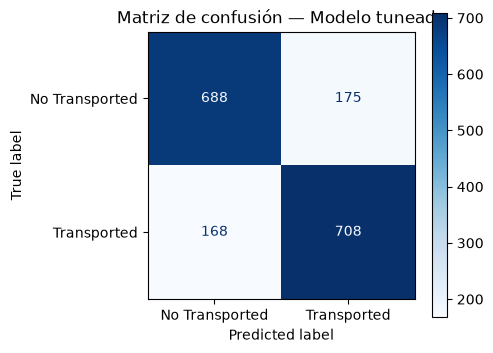


Matriz de confusión:
[[688 175]
 [168 708]]


In [29]:
cm = confusion_matrix(y_test, y_pred_tuneado)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Transported", "Transported"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de confusión — Modelo tuneado")
plt.tight_layout()
plt.show()

print("\nMatriz de confusión:")
print(cm)

**Interpretación de errores:**

- Falsos negativos (pasajeros SÍ transportados que el modelo predijo que NO): 168
- Falsos positivos (pasajeros NO transportados que el modelo predijo que SÍ): 175

Están casi parejos (168 vs 175 de 1,739), así que el modelo no se está inclinando hacia predecir una clase más que la otra. Aquí no hay un error "peor" que el otro como en fraude o diagnóstico médico, así que tiene sentido seguir usando F1 como criterio principal, igual que en las secciones anteriores.

## 3.3 Comparación: baseline vs modelo anterior vs modelo tuneado

In [30]:
def calcular_metricas(modelo, X, y, nombre):
    y_pred = modelo.predict(X)
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
    }

resultados = [
    calcular_metricas(baseline_model, X_test, y_test, "Baseline (default)"),
    calcular_metricas(modelo_rf, X_test, y_test, "Modelo anterior (avance 2)"),
    calcular_metricas(modelo_rf_tuned, X_test, y_test, "Modelo tuneado"),
]

tabla_comparativa = pd.DataFrame(resultados).set_index("Modelo")
print("=== Tabla comparativa ===")
tabla_comparativa.round(4)

=== Tabla comparativa ===


,Accuracy,Precision,Recall,F1-score
Modelo,,,,
Baseline (default),0.7936,0.8301,0.7420,0.7836
Modelo anterior (avance 2),0.7987,0.8009,0.7991,0.8000
Modelo tuneado,0.8028,0.8018,0.8082,0.8050


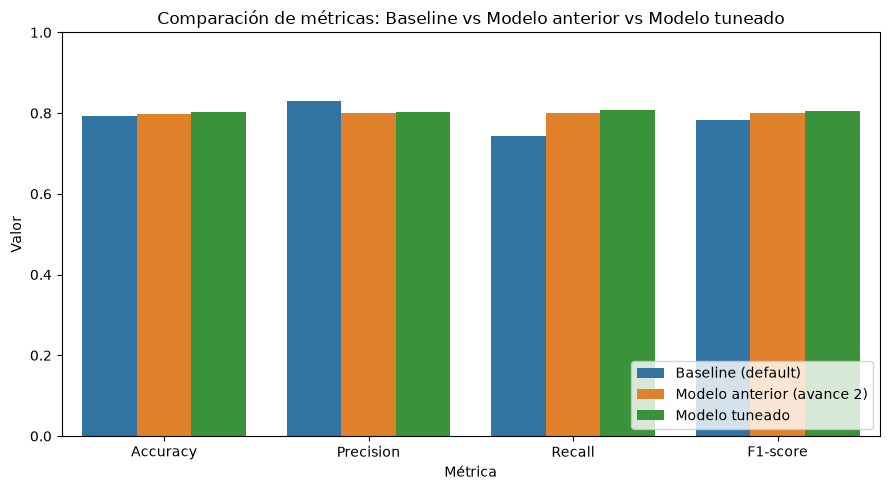

In [31]:
tabla_plot = tabla_comparativa.reset_index().melt(
    id_vars="Modelo", var_name="Métrica", value_name="Valor"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=tabla_plot, x="Métrica", y="Valor", hue="Modelo")
plt.ylim(0, 1)
plt.title("Comparación de métricas: Baseline vs Modelo anterior vs Modelo tuneado")
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()

## 3.4 Justificación del tuning

El tuning sí mejoró el modelo, pero por poco: F1 de 0.8050 contra 0.8000 del avance 2 (+0.005 en test, +0.01 en CV, prácticamente lo mismo). El salto fuerte no está ahí, sino entre el baseline sin ajustar (F1 0.7836) y el modelo del avance 2, es decir, la ganancia real ya se había conseguido casi toda al escoger `n_estimators=200, max_depth=10` a mano en el avance 2.

Tiene sentido con lo que vimos en las curvas de validación de la Sección 1: `max_depth=10` ya estaba prácticamente en el punto óptimo, así que a `RandomizedSearchCV` no le quedaba mucho margen para mejorar. Lo que sí cambió fue el balance precision/recall: el baseline es más conservador (precision 0.83, recall 0.74), mientras que el modelo anterior y el tuneado quedan bastante más parejos entre las dos métricas y el tuneado sube un poco más el recall (0.8082) sin perder precision, que es de donde sale su F1 ligeramente más alto.

# 4. Componente Individual

Cada integrante del equipo trabaja de forma independiente con un modelo de una familia distinta a Random Forest, lo tunea con al menos 3 hiperparámetros, lo evalúa con las mismas métricas del equipo, y compara sus resultados contra el modelo final del equipo (`modelo_rf_tuned`).

## Ana Paula Moreno

**Modelo elegido: Regresión Logística**

Elijo Regresión Logística por ser una familia completamente distinta a Random Forest: en vez de construir árboles de decisión, ajusta una combinación lineal de las variables (con pesos aprendidos) y la pasa por una función sigmoide para obtener una probabilidad. Al igual que SVM, es sensible a la escala de las variables, así que agrego un `StandardScaler` dentro de un `Pipeline`. La ventaja frente a Random Forest es la interpretabilidad: cada variable tiene un peso (coeficiente) que indica qué tanto y en qué dirección empuja la predicción, algo que Random Forest no ofrece de forma tan directa.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay, roc_auc_score

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Al menos 3 hiperparámetros: C, penalty y solver
param_grid_logreg = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__penalty": ["l1", "l2"],
    "logreg__solver": ["liblinear", "saga"],
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

grid_logreg.fit(X_train, y_train)

print("Mejores hiperparámetros Regresión Logística:", grid_logreg.best_params_)
print("Mejor F1 promedio en CV:", round(grid_logreg.best_score_, 4))

modelo_logreg = grid_logreg.best_estimator_

/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 ins

Mejores hiperparámetros Regresión Logística: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Mejor F1 promedio en CV: 0.779


/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Evaluación de la Regresión Logística tuneada sobre el conjunto de prueba

In [33]:
y_pred_logreg = modelo_logreg.predict(X_test)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, modelo_logreg.predict_proba(X_test)[:, 1])

print("=== Métricas de Regresión Logística (conjunto de prueba) ===")
print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall:    {recall_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")
print(f"ROC-AUC:   {auc_logreg:.4f}")

=== Métricas de Regresión Logística (conjunto de prueba) ===
Accuracy:  0.7907
Precision: 0.7889
Recall:    0.7979
F1-score:  0.7934
ROC-AUC:   0.8677


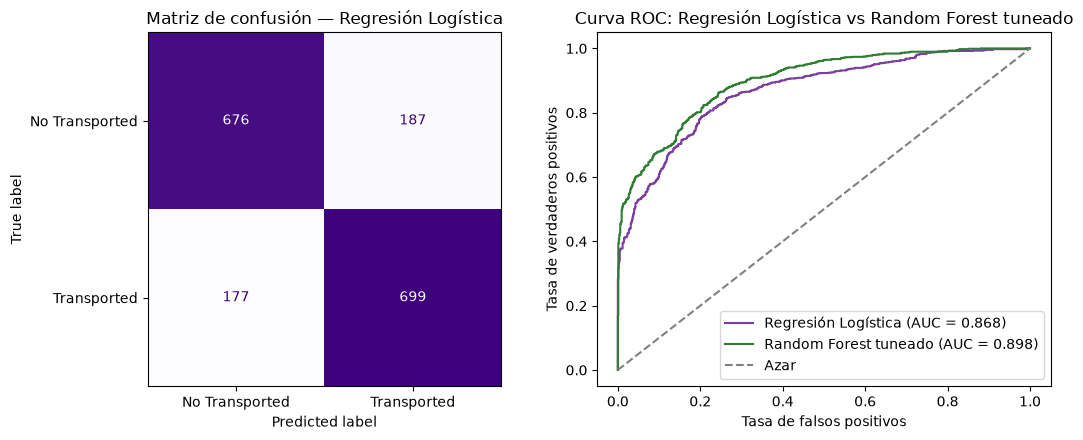

Matriz de confusión (Regresión Logística):
[[676 187]
 [177 699]]


In [35]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=["No Transported", "Transported"])
disp_logreg.plot(ax=axes[0], cmap="Purples", colorbar=False)
axes[0].set_title("Matriz de confusión — Regresión Logística")

# Curva ROC calculada manualmente (evita problemas de versión con RocCurveDisplay)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, modelo_logreg.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1])

axes[1].plot(fpr_logreg, tpr_logreg, color="#7B3FA0", label=f"Regresión Logística (AUC = {auc_logreg:.3f})")
axes[1].plot(fpr_rf, tpr_rf, color="#2E7D32", label=f"Random Forest tuneado (AUC = {roc_auc_score(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1]):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC: Regresión Logística vs Random Forest tuneado")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Matriz de confusión (Regresión Logística):")
print(cm_logreg)

In [36]:
resultados_individual = [
    calcular_metricas(modelo_rf_tuned, X_test, y_test, "Modelo del equipo (RF tuneado)"),
    {
        "Modelo": "Regresión Logística (Ana Paula)",
        "Accuracy": accuracy_logreg,
        "Precision": precision_logreg,
        "Recall": recall_logreg,
        "F1-score": f1_logreg,
    },
]

tabla_individual = pd.DataFrame(resultados_individual).set_index("Modelo")
print("=== Regresión Logística vs modelo del equipo ===")
tabla_individual.round(4)

=== Regresión Logística vs modelo del equipo ===


,Accuracy,Precision,Recall,F1-score
Modelo,,,,
Modelo del equipo (RF tuneado),0.8028,0.8018,0.8082,0.8050
Regresión Logística (Ana Paula),0.7907,0.7889,0.7979,0.7934


### ¿Cambiarías la decisión del equipo?

No. Random Forest gana en las cuatro métricas: F1 de 0.8050 vs 0.7934, y también en Accuracy, Precision y Recall. La diferencia se nota más en ROC-AUC (0.898 vs 0.868), así que no es cosa de un solo umbral. Random Forest es mejor en general.

Tiene sentido: mi modelo solo combina las variables de forma lineal, mientras que Random Forest puede capturar interacciones entre ellas (por ejemplo, que el efecto del gasto en amenidades dependa de la cabina), algo que la Regresión Logística no ve a menos que alguien la construya a mano como feature.

Gano en interpretabilidad (los coeficientes dicen exactamente qué pesa cada variable), pero aquí no compensa perder ~1.2 puntos de F1 y ~3 de ROC-AUC. Para explicarle el modelo a alguien no técnico, usaría la mía; para la competencia de Kaggle, Random Forest sigue siendo la mejor decisión del equipo.